# Unit 5 — Combining models

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`). Run the first cell before the others.

In [1]:
%config InlineBackend.figure_format = "svg"
import os
import sys
sys.path.insert(0, "website")          # plot style lives in website/weather.py
from weather import use_style
use_style()
if os.path.basename(os.getcwd()) != "website":
    os.chdir("website")                # so the programs find data/seattle_weather.csv

## Practice 1 — Implement CART learning algorithms to perform categorization

Sort each day into its weather type (sun, rain, fog, drizzle, snow) from its measurements. CART (Classification And Regression Trees) builds a tree of yes/no questions. At each step it picks the question that makes the two groups purest, measured by Gini impurity.

|--- precipitation <= 0.15
|   |--- wind <= 1.95
|   |   |--- temp_max <= 4.70
|   |   |   |--- class: drizzle
|   |   |--- temp_max >  4.70
|   |   |   |--- class: sun
|   |--- wind >  1.95
|   |   |--- temp_max <= 16.40
|   |   |   |--- class: sun
|   |   |--- temp_max >  16.40
|   |   |   |--- class: sun
|--- precipitation >  0.15
|   |--- temp_min <= 0.85
|   |   |--- precipitation <= 3.15
|   |   |   |--- class: rain
|   |   |--- precipitation >  3.15
|   |   |   |--- class: snow
|   |--- temp_min >  0.85
|   |   |--- temp_min <= 3.05
|   |   |   |--- class: rain
|   |   |--- temp_min >  3.05
|   |   |   |--- class: rain

Test accuracy: 0.833

A day with 5 mm rain, 12 °C max, 6 °C min, wind 4 -> rain


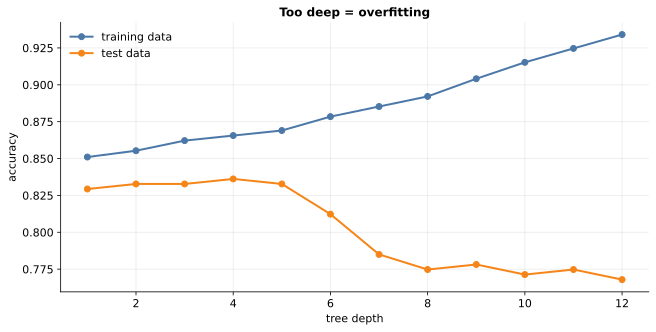

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score

df = pd.read_csv("data/seattle_weather.csv")
columns = ["precipitation", "temp_max", "temp_min", "wind"]
X = df[columns]
y = df["weather"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CART with Gini impurity, at most 3 questions deep
tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# The learned rules. Some splits give the same class on both sides:
# they still make the groups purer (lower Gini), so CART keeps them.
print(export_text(tree, feature_names=columns))

y_pred = tree.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()

# Classify one new day
new_day = pd.DataFrame({"precipitation": [5.0], "temp_max": [12.0], "temp_min": [6.0], "wind": [4.0]})
print("A day with 5 mm rain, 12 °C max, 6 °C min, wind 4 ->", tree.predict(new_day)[0])

# Plot: deeper trees fit the training data better, but not the test data
depths = range(1, 13)
train_acc = []
test_acc = []
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.figure(figsize=(9, 4.5))
plt.plot(depths, train_acc, "o-", label="training data")
plt.plot(depths, test_acc, "o-", label="test data")
plt.xlabel("tree depth")
plt.ylabel("accuracy")
plt.title("Too deep = overfitting")
plt.legend()
plt.show()

## Practice 2 — Implement Ensemble learning models to perform classification

An ensemble combines many models into one, usually stronger, model. Bagging trains trees on random samples of the data and lets them vote. A random forest also picks random columns. AdaBoost trains models one after another, each one fixing the mistakes of the last. Voting combines different kinds of models.

Single tree (no depth limit) accuracy: 0.73
Bagging accuracy: 0.809


Random forest accuracy: 0.816
AdaBoost accuracy: 0.812


Voting accuracy: 0.829


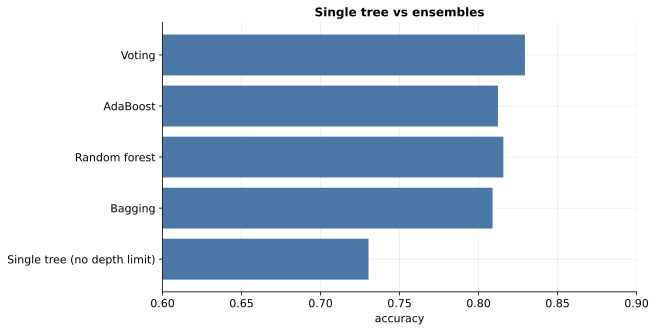

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("data/seattle_weather.csv")
columns = ["precipitation", "temp_max", "temp_min", "wind"]
X = df[columns]
y = df["weather"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# A tree with no depth limit overfits (see the depth plot in Practice 1).
# Bagging and random forests fix that without having to choose a depth.
models = {
    "Single tree (no depth limit)": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42),
    "Random forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=50, random_state=42),
    "Voting": VotingClassifier([
        ("tree", DecisionTreeClassifier(max_depth=3, random_state=42)),
        ("forest", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("logistic", LogisticRegression(max_iter=1000)),
    ]),
}

accuracies = {}
for name in models:
    model = models[name]
    model.fit(X_train, y_train)
    accuracies[name] = accuracy_score(y_test, model.predict(X_test))
    print(name, "accuracy:", round(accuracies[name], 3))

# Plot: compare the accuracies
plt.figure(figsize=(9, 4.5))
plt.barh(list(accuracies.keys()), list(accuracies.values()))
plt.xlim(0.6, 0.9)
plt.xlabel("accuracy")
plt.title("Single tree vs ensembles")
plt.show()